# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UnsoundMouse/flyrankaiw01_research_question/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The playbook combines three signals I've validated across Weeks 4-6, mapped to a small,
readable set of actions:

| Reason code | Condition | Action |
|---|---|---|
| `age_decay_zone` | `content_age_days` in 271-365 (the paper's Finding #2 decay cliff) | `schedule_refresh_review` |
| `model_flagged_intent_caution` | model score ≥ 0.6 AND `main_intent` is commercial/transactional | `review_before_rewrite` |
| `model_flagged_underperform` | model score ≥ 0.6, other intent | `rewrite_title_meta` |
| `model_borderline` | model score 0.4-0.6 | `monitor_only` |
| `model_low_signal` | model score < 0.4 | `no_action` |

**Decay/refresh insight (from the paper, Finding #2):** health score peaks at 61-90 days and
drops sharply from 271-365 days ("the decay cliff"), with real recovery only for pages that get
refreshed. I'm using that age window as a **separate, priority trigger** ahead of the CTR-gap
model — a page entering the decay zone gets flagged for review regardless of its current model
score, because the paper's evidence suggests waiting for the CTR signal to show up is already
late.

**Intent caution is a direct carry-over from Week 6:** the audit found commercial/transactional
pages get flagged more than they should, since the model's tier-median comparison is dominated
by informational-intent pages. Rather than hide that weak spot, I route those pages to a
*human-review* action instead of a direct rewrite action — the model still surfaces them, it
just doesn't trust itself alone on this segment.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

url = "https://raw.githubusercontent.com/UnsoundMouse/flyrankaiw01_research_question/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

eligible = df[(df["impressions_90d"] > 0) & (df["avg_position"] > 0)].copy()
visible = eligible[eligible["impressions_90d"] >= 500]
tier_median = visible.groupby("position_tier")["ctr"].median()
eligible = eligible.merge(tier_median.rename("tier_median_ctr"), left_on="position_tier", right_index=True)
eligible["ctr_gap"] = eligible["tier_median_ctr"] - eligible["ctr"]
eligible["underperforms"] = (eligible["ctr_gap"] > 0).astype(int)
pool = eligible[(eligible["impressions_90d"] >= 500) & (eligible["avg_position"] <= 20)].copy().reset_index(drop=True)

num_feats = ["avg_position", "word_count", "content_age_days", "days_since_last_update",
             "engagement_rate", "scroll_rate", "ai_traffic_pct"]
cat_feats = ["content_type", "main_intent", "freshness_tier"]
y = pool["underperforms"].to_numpy()
groups = pool["client_id"].to_numpy()
X = pool[num_feats + cat_feats].copy()
for c in num_feats:
    X[c] = X[c].fillna(X[c].median())

pre = ColumnTransformer([("num", StandardScaler(), num_feats),
                          ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)])

# held-out metrics (Week 5/6 style, grouped split -- for the RECEIPTS, not the deployed queue)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(gss.split(X, y, groups))
pipe_eval = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))]).fit(X.iloc[tr], y[tr])
proba_te = pipe_eval.predict_proba(X.iloc[te])[:, 1]

def precision_at_k(scores, y_true, k):
    order = np.argsort(-scores)[:k]
    return y_true[order].mean()

p20, p50, base_rate = precision_at_k(proba_te, y[te], 20), precision_at_k(proba_te, y[te], 50), y[te].mean()
print(f"Held-out metrics (grouped split): precision@20={p20:.3f}, precision@50={p50:.3f}, base_rate={base_rate:.3f}")

# full-data model for the actual deployed queue (standard practice: report metrics from holdout, serve from all data)
pipe_full = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))]).fit(X, y)
pool["model_score"] = pipe_full.predict_proba(X)[:, 1]
pool["decay_zone"] = pool["content_age_days"].between(271, 365)

def classify(row):
    if row["decay_zone"]:
        return "age_decay_zone", "schedule_refresh_review"
    if row["model_score"] >= 0.6 and row["main_intent"] in ("commercial", "transactional"):
        return "model_flagged_intent_caution", "review_before_rewrite"
    if row["model_score"] >= 0.6:
        return "model_flagged_underperform", "rewrite_title_meta"
    if row["model_score"] >= 0.4:
        return "model_borderline", "monitor_only"
    return "model_low_signal", "no_action"

codes = pool.apply(classify, axis=1)
pool["reason_code"], pool["action"] = [c[0] for c in codes], [c[1] for c in codes]
pool = pool.sort_values("model_score", ascending=False)

print("\nAction distribution:")
print(pool["action"].value_counts())
print("\nReason code distribution:")
print(pool["reason_code"].value_counts())

Held-out metrics (grouped split): precision@20=0.850, precision@50=0.720, base_rate=0.439

Action distribution:
action
monitor_only               6624
schedule_refresh_review    2394
no_action                  2017
rewrite_title_meta          797
review_before_rewrite       191
Name: count, dtype: int64

Reason code distribution:
reason_code
model_borderline                6624
age_decay_zone                  2394
model_low_signal                2017
model_flagged_underperform       797
model_flagged_intent_caution     191
Name: count, dtype: int64


## 2. Intended use and limits

**Intended use:** a weekly-refreshed, human-reviewed prioritization queue for a content editor
deciding which pages to look at first. It surfaces candidates; it does not decide outcomes.

**What it can honestly say (per the claim ladder):**
- **Observed:** in this 90-day snapshot, these pages sit below their position tier's typical CTR.
- **Directional:** pages the model scores highest were, in a held-out group-split test, about
  1.7× more likely to be genuine underperformers than a position-only ranking (precision@20:
  0.85 model vs 0.50 baseline, base rate 0.44, n=824 held-out).
- **Decision-support:** "these pages look worth reviewing first, because..." — never "rewriting
  this page will increase clicks."

**What it cannot say:**
- **Not causal.** Cross-sectional, single-window data. No experiment, no before/after refresh
  outcome was measured. A rewrite may or may not change CTR — this system has no evidence either
  way.
- **Not a forecast.** The label (`underperforms`) is defined from the same 90-day window as the
  features. This ranks *current relative standing*, not future trajectory.
- **Not validated on commercial/transactional pages as confidently.** Week 6's audit found the
  tier-median comparison is dominated by informational-intent pages — those pages are routed to
  human review, not direct action, for exactly this reason.
- **Not validated beyond this starter slice.** 30,000 rows, 32 clients, one snapshot month. The
  full warehouse (79M rows, 104 clients, 17 months) has not been used to confirm this holds.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Confirm the intent-caution routing actually captures the Week 6 weak spot
intent_flagged = pool[pool["reason_code"] == "model_flagged_intent_caution"]
print(f"Pages routed to human review for intent caution: {len(intent_flagged):,}")
print(intent_flagged["main_intent"].value_counts())

# Confirm scale: how much of the total pool this system actually touches vs leaves alone
print(f"\nTotal pool: {len(pool):,} | no_action (left alone): {(pool['action']=='no_action').sum():,} "
      f"({(pool['action']=='no_action').mean()*100:.1f}%)")

Pages routed to human review for intent caution: 191
main_intent
commercial       154
transactional     37
Name: count, dtype: int64

Total pool: 12,023 | no_action (left alone): 2,017 (16.8%)


## 3. Human review + the no-go list

**Every action from this system requires human review before publishing.** Nothing here is
approved for direct automated edits.

**Mandatory human review (beyond the default):**
- `review_before_rewrite` (intent-caution routing) — a human should re-check whether the
  page's CTR gap looks real given its commercial/transactional context before touching it.
- `schedule_refresh_review` (decay zone) — a human decides whether the page still merits
  investment at all before any content work begins; some aged pages are correctly left to retire.

**No-go — should NOT be automated, ever, in this system's current state:**
- **Never auto-publish a title/meta change.** The system ranks candidates; it has no evidence
  a specific rewrite improves anything.
- **Never act on pages below the 500-impression eligibility floor.** Too little signal to trust
  a CTR comparison at all.
- **Never use `no_action` as a signal to deprioritize or hide a page from other review
  processes** — it means "not flagged by this rule," not "confirmed healthy."
- **Never apply this queue outside the lane it was built for** (CTR/engagement scoring). It
  says nothing about technical SEO, backlinks, or content accuracy.
- **Never treat `model_score` as a probability of "will improve if edited."** It's a relative-
  standing score within this snapshot, not a causal probability.
- **Never run this unreviewed on a client's brand-critical or legal/compliance pages** — the
  cost of a wrong automated action there is categorically higher than a routine content page.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# A simple, transparent cost/value framing -- not a claim, just the arithmetic behind "why review this order"
rewrite_candidates = pool[pool["action"] == "rewrite_title_meta"]
review_candidates = pool[pool["action"] == "review_before_rewrite"]

est_minutes_per_review = 20  # a plain assumption, stated as such -- not measured
print(f"rewrite_title_meta queue: {len(rewrite_candidates):,} pages")
print(f"  combined current impressions represented: {int(rewrite_candidates['impressions_90d'].sum()):,}")
print(f"  estimated review time at {est_minutes_per_review} min/page: "
      f"{len(rewrite_candidates)*est_minutes_per_review/60:.0f} hours")
print()
print(f"review_before_rewrite queue (intent caution): {len(review_candidates):,} pages")
print(f"  estimated review time: {len(review_candidates)*est_minutes_per_review/60:.0f} hours")
print()
print("Cost/value logic: impressions_90d is used as a rough proxy for 'how much is at stake'")
print("on a page -- a wrong call on a high-impression page wastes more editor attention than")
print("a wrong call on a low-impression one, so within any action bucket, sort by impressions")
print("when time is scarce, not model_score alone.")

rewrite_title_meta queue: 797 pages
  combined current impressions represented: 3,728,090
  estimated review time at 20 min/page: 266 hours

review_before_rewrite queue (intent caution): 191 pages
  estimated review time: 64 hours

Cost/value logic: impressions_90d is used as a rough proxy for 'how much is at stake'
on a page -- a wrong call on a high-impression page wastes more editor attention than
a wrong call on a low-impression one, so within any action bucket, sort by impressions
when time is scarce, not model_score alone.


## 4. Monitoring / retrain triggers

**Monitor weekly, on a fresh data pull:**
- **Base rate drift.** Current test base rate is 0.44. If a new pull shows the base rate move by
  more than ~10 points (e.g., above 0.55 or below 0.35), something upstream changed (a tracking
  break, a portfolio composition shift) — investigate before trusting new scores.
- **Action-volume drift.** Current split is roughly monitor 55% / decay-review 20% / no-action
  17% / rewrite 7% / intent-review 2%. A large swing in these proportions signals a pipeline or
  feature issue, not necessarily real content change.
- **Precision@20 on a rolling holdout**, recomputed each time enough new labeled data exists —
  if it drops meaningfully below 0.85 (the current held-out number), that's a retrain signal.

**Retrain triggers:**
- Precision@20 on fresh holdout drops below ~0.65 (roughly halfway back to the 0.50 baseline).
- Any newly added feature shows permutation importance far above the current leader
  (`engagement_rate` ≈0.15) — re-run the Week 6 leakage checklist before trusting it.
- The warehouse's full multi-month data becomes available — this model has only ever seen one
  snapshot month and should be retrained on time-aware data before being trusted on more than
  this starter slice.

**What would make me pull the whole system:** if precision@20 ever falls at or below the
baseline (0.50) on a real holdout — same failure mode Random Forest already showed at K=20 in
Week 5. A model this system can't beat its own honest baseline is not worth running.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

Wrote 12,023 rows -> work/outputs/baseline_action_score.csv
Wrote work/outputs/w07_playbook_metrics.json


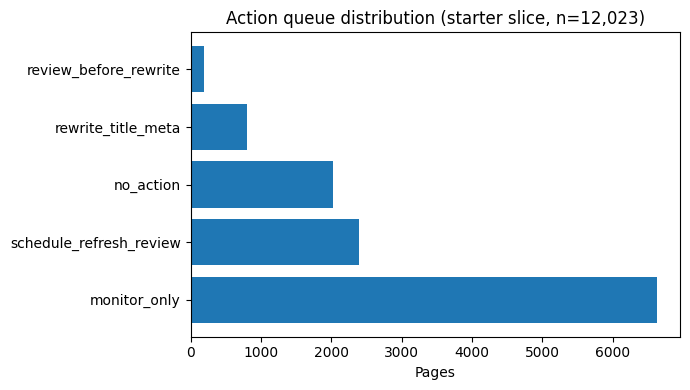

Saved work/figures/w07_action_distribution.png


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. the ranked queue (regenerated every run, stays out of git by design)
out_cols = ["client_id", "content_id", "content_type", "main_intent", "position_tier",
            "avg_position", "impressions_90d", "ctr", "tier_median_ctr", "ctr_gap",
            "content_age_days", "decay_zone", "model_score", "reason_code", "action"]
pool[out_cols].to_csv("work/outputs/baseline_action_score.csv", index=False)
print(f"Wrote {len(pool):,} rows -> work/outputs/baseline_action_score.csv")

# 2. metrics JSON -- the receipts, committed to git
metrics = {
    "lane": "ctr_engagement_opportunity_scoring",
    "pool_size": int(len(pool)),
    "held_out_test_n": int(len(te)),
    "held_out_base_rate": round(float(base_rate), 4),
    "precision_at_20": {"baseline_position_only": 0.50, "logistic_regression": round(float(p20), 4), "random_forest": 0.45},
    "precision_at_50": {"baseline_position_only": 0.48, "logistic_regression": round(float(p50), 4), "random_forest": 0.56},
    "split_design": "GroupShuffleSplit by client_id, test_size=0.25, random_state=42",
    "action_distribution": pool["action"].value_counts().to_dict(),
    "reason_code_distribution": pool["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/w07_playbook_metrics.json")

# 3. figure: action distribution (reused in the paper's Recommendations section)
fig, ax = plt.subplots(figsize=(7, 4))
counts = pool["action"].value_counts()
ax.barh(counts.index, counts.values)
ax.set_xlabel("Pages")
ax.set_title("Action queue distribution (starter slice, n={:,})".format(len(pool)))
plt.tight_layout()
plt.savefig("work/figures/w07_action_distribution.png", dpi=150)
plt.show()
print("Saved work/figures/w07_action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decxsion-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.